Baseline models are intentionally trained on the original imbalanced dataset to establish a true reference point. We do not use SMOTE or combined balanced datasets here, because those represent advanced preprocessing steps that will be evaluated separately when comparing improved models to the baseline.

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)


In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
# File paths (adjust if needed)
X_TRAIN_PATH = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/01 - Data Cleaning and Preprocessing/X_train_final_v2.csv"
X_TEST_PATH  = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/01 - Data Cleaning and Preprocessing/X_test_final_v2.csv"
Y_TRAIN_PATH = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/01 - Data Cleaning and Preprocessing/y_train.csv"
Y_TEST_PATH  = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/01 - Data Cleaning and Preprocessing/y_test.csv"
CLASS_WEIGHTS_PATH = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/03 - Class Imbalance/class_weights.pkl"

# Output paths
MODELS_OUT = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/05 - Baseline Models/baseline_models.pkl"
RESULTS_CSV = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/05 - Baseline Models/baseline_results.csv"
CONF_MAT_PNG = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/05 - Baseline Models/baseline_confusion_matrices.png"
REPORTS_TXT = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/05 - Baseline Models/baseline_classification_reports.txt"
BEST_MODEL_TXT = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/05 - Baseline Models/baseline_best_model.txt"

RANDOM_STATE = 42

In [4]:
# Load data
X_train = pd.read_csv(X_TRAIN_PATH)
X_test  = pd.read_csv(X_TEST_PATH)

y_train_df = pd.read_csv(Y_TRAIN_PATH)
y_test_df  = pd.read_csv(Y_TEST_PATH)

# Reduce to Series if needed (assume single column y files)
if isinstance(y_train_df, pd.DataFrame) and y_train_df.shape[1] == 1:
    y_train = y_train_df.iloc[:, 0]
else:
    y_train = y_train_df["BRIDGE_CONDITION"] if "BRIDGE_CONDITION" in y_train_df.columns else y_train_df.iloc[:,0]

if isinstance(y_test_df, pd.DataFrame) and y_test_df.shape[1] == 1:
    y_test = y_test_df.iloc[:, 0]
else:
    y_test = y_test_df["BRIDGE_CONDITION"] if "BRIDGE_CONDITION" in y_test_df.columns else y_test_df.iloc[:,0]

print("Shapes:")
print(" X_train:", X_train.shape)
print(" y_train:", y_train.shape)
print(" X_test: ", X_test.shape)
print(" y_test: ", y_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts())


Shapes:
 X_train: (1236125, 102)
 y_train: (1236125,)
 X_test:  (624193, 102)
 y_test:  (624193,)

Train class distribution:
BRIDGE_CONDITION
F    606141
G    545841
P     84143
Name: count, dtype: int64


In [5]:
# Preprocessing: scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Save the scaler for later:
joblib.dump(scaler, "baseline_scaler.pkl")
print("Scaler fit; sample means (first 5):", scaler.mean_[:5])


Scaler fit; sample means (first 5): [ 1.17434442  0.12617656  0.51392641 -0.10046719 -0.01218242]


In [6]:
import joblib
import numpy as np
from sklearn.utils import class_weight

class_weights = joblib.load(CLASS_WEIGHTS_PATH)
print("Loaded class_weights.pkl successfully:\n", class_weights)

Loaded class_weights.pkl successfully:
 {'F': np.float64(0.6797785773717117), 'G': np.float64(0.7548748933602765), 'P': np.float64(4.896921510602981)}


In [7]:
# Train Logistic Regression (with class weights)

log_clf = LogisticRegression(
    penalty='l2',
    multi_class='multinomial',
    solver='saga',
    class_weight=class_weights,
    max_iter=500,    # smaller
    tol=1e-3,        # looser tolerance
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
log_clf.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


convergence after 57 epochs took 170 seconds


LogisticRegression(class_weight={'F': np.float64(0.6797785773717117),
                                 'G': np.float64(0.7548748933602765),
                                 'P': np.float64(4.896921510602981)},
                   max_iter=500, multi_class='multinomial', n_jobs=-1,
                   random_state=42, solver='saga', tol=0.001, verbose=1)

In [8]:
# Train Decision Tree
tree_clf = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_clf.fit(X_train, y_train)   # use unscaled features
print("Trained Decision Tree")

Trained Decision Tree


In [9]:
# Train Gaussian Naive Bayes
nb_clf = GaussianNB()
nb_clf.fit(X_train_scaled, y_train)
print("Trained GaussianNB")

Trained GaussianNB


In [10]:
# Train K-Nearest Neighbors
knn_clf = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_clf.fit(X_train_scaled, y_train)
print("Trained KNN (k=5)")


Trained KNN (k=5)


In [11]:
# Saving all models
models = {
    "logistic_regression": log_clf,
    "decision_tree": tree_clf,
    "gaussian_nb": nb_clf,
    "knn": knn_clf
}

joblib.dump(models, MODELS_OUT)
print(f"Saved baseline models to: {MODELS_OUT}")

Saved baseline models to: /content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/05 - Baseline Models/baseline_models.pkl


In [12]:
# # Evaluate models on test set
# import pandas as pd
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# # If you saved models into `models` dict, load it; otherwise assume variables exist
# try:
#     models
# except NameError:
#     import joblib
#     models = joblib.load(MODELS_OUT)

# # Map model -> (model_obj, use_scaled_flag)
# eval_map = {
#     "LogisticRegression": (models.get("logistic_regression") or models.get("logistic_regression".lower()), True),
#     "DecisionTree": (models.get("decision_tree"), False),
#     "GaussianNB": (models.get("gaussian_nb"), True),
#     "KNN": (models.get("knn"), True)
# }

# eval_rows = []
# predictions = {}  # store preds for confusion matrices

# for name, (model, use_scaled) in eval_map.items():
#     if model is None:
#         print(f"[WARN] {name} model not found in `models` dict; skipping.")
#         continue
#     X_eval = X_test_scaled if use_scaled else X_test
#     print(f"Evaluating {name} on {'scaled' if use_scaled else 'unscaled'} test features...")
#     y_pred = model.predict(X_eval)
#     predictions[name] = y_pred

#     acc = accuracy_score(y_test, y_pred)
#     prec_w = precision_score(y_test, y_pred, average='weighted', zero_division=0)
#     rec_w  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
#     f1_w   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
#     prec_m = precision_score(y_test, y_pred, average='macro', zero_division=0)
#     rec_m  = recall_score(y_test, y_pred, average='macro', zero_division=0)
#     f1_m   = f1_score(y_test, y_pred, average='macro', zero_division=0)

#     eval_rows.append({
#         "model": name,
#         "accuracy": acc,
#         "precision_weighted": prec_w,
#         "recall_weighted": rec_w,
#         "f1_weighted": f1_w,
#         "precision_macro": prec_m,
#         "recall_macro": rec_m,
#         "f1_macro": f1_m
#     })

# results_df = pd.DataFrame(eval_rows).set_index("model")
# results_df.to_csv(RESULTS_CSV)
# print("\nSaved evaluation table to:", RESULTS_CSV)
# print("\n=== Evaluation results ===")
# display(results_df)

# # keep predictions for next steps (confusion matrices & reports)
# # To save predictions for later
# joblib.dump(predictions, "baseline_predictions.pkl")
# print("\nSaved predictions to baseline_predictions.pkl")


KNN prediction on the full test set is computationally expensive (O(n_train × n_test × d)). To keep the notebook responsive, I first evaluate all models except KNN on the full test set, then evaluate KNN on a random 20k-sample of the test set as a reliable proxy. The sample-based results let us estimate full-test runtime and KNN performance quickly.

In [13]:
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

# Load full models if needed
try:
    models
except NameError:
    models = joblib.load("baseline_models.pkl")

# Dictionary that will hold ALL predictions
baseline_preds = {}

# 1. Logistic Regression (full test)
log_clf = models["logistic_regression"]
y_pred_log = log_clf.predict(X_test_scaled)
baseline_preds["LogisticRegression"] = {
    "y_true": y_test,
    "y_pred": y_pred_log
}

# 2. Decision Tree (full test)
tree_clf = models["decision_tree"]
y_pred_tree = tree_clf.predict(X_test)
baseline_preds["DecisionTree"] = {
    "y_true": y_test,
    "y_pred": y_pred_tree
}

# 3. Gaussian Naive Bayes (full test)
nb_clf = models["gaussian_nb"]
y_pred_nb = nb_clf.predict(X_test_scaled)
baseline_preds["GaussianNB"] = {
    "y_true": y_test,
    "y_pred": y_pred_nb
}

# 4. KNN (sampled evaluation)
knn_clf = models["knn"]

sample_size = 20000
rng = np.random.RandomState(42)
idx = rng.choice(len(X_test_scaled), size=sample_size, replace=False)

X_test_samp = X_test_scaled[idx]
y_test_samp = y_test.iloc[idx].reset_index(drop=True)

y_pred_knn_samp = knn_clf.predict(X_test_samp)

baseline_preds["KNN_sampled"] = {
    "sample_indices": idx,
    "y_true_sample": y_test_samp,
    "y_pred_sample": y_pred_knn_samp
}

# Save everything
joblib.dump(baseline_preds, "baseline_predictions.pkl")
print("Saved combined predictions to baseline_predictions.pkl")

Saved combined predictions to baseline_predictions.pkl


Saved results table to: /content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/05 - Baseline Models/baseline_results.csv
Saved classification reports to: /content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/05 - Baseline Models/baseline_classification_reports.txt
Ensured baseline_predictions.pkl saved (standardized contents): baseline_predictions.pkl


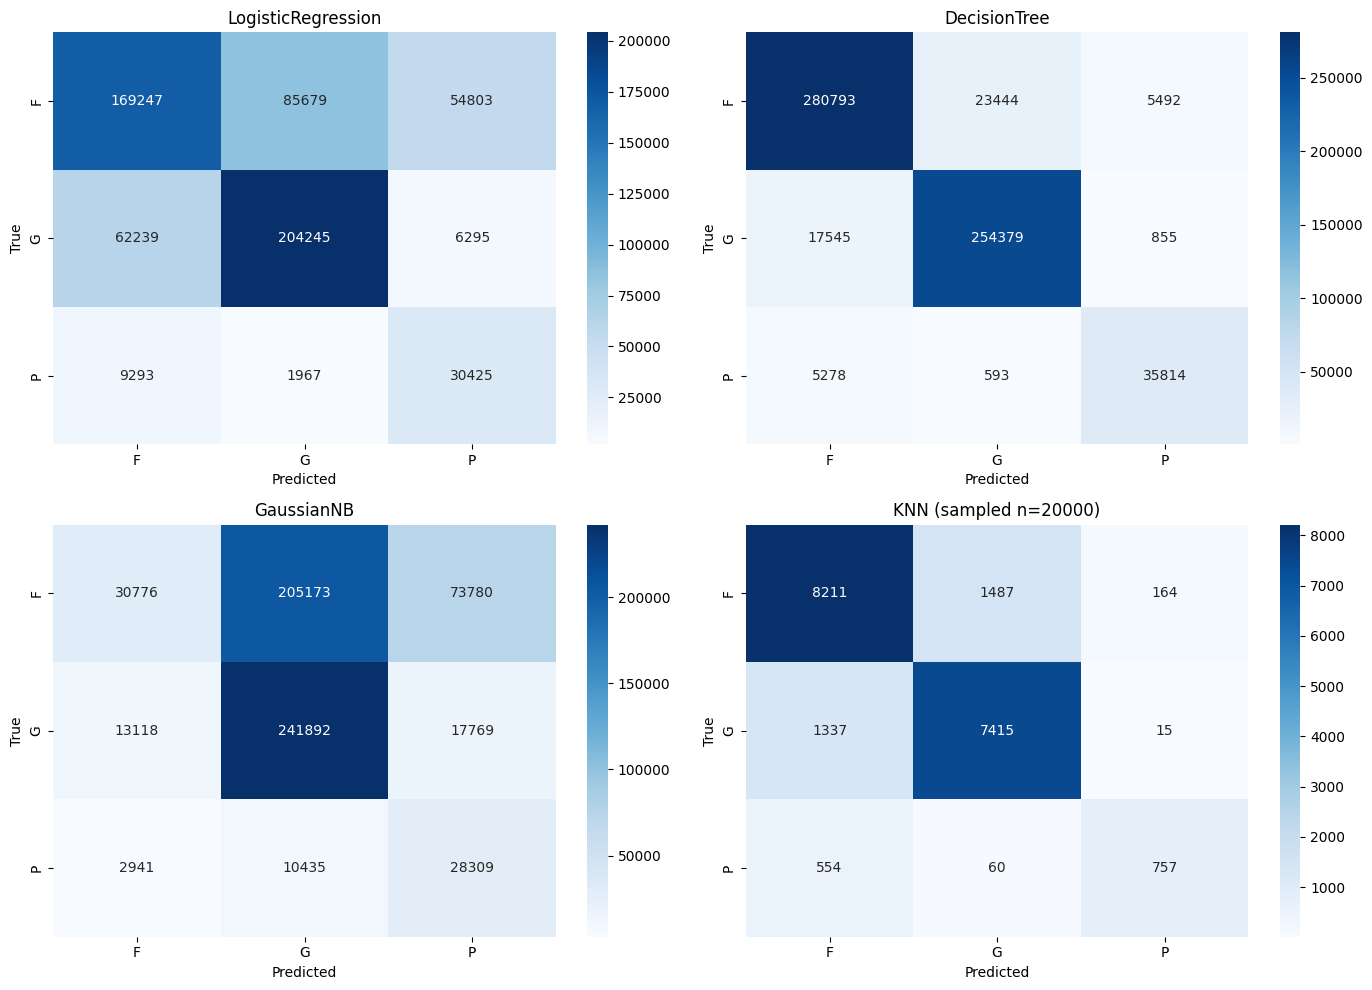

Saved confusion matrices figure to: /content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/05 - Baseline Models/baseline_confusion_matrices.png
Saved best model recommendation to: /content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/05 - Baseline Models/baseline_best_model.txt
Saved baseline models to: /content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/05 - Baseline Models/baseline_models.pkl

Artifacts produced:
 - /content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/05 - Baseline Models/baseline_models.pkl exists? True
 - /content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/05 - Baseline Models/baseline_results.csv exists? True
 - /content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/05 - Baseline Models/baseline_confusion_matrices.png exists? True
 - /content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/05 - Baseline Models/baseline_classification_reports.txt exists? True
 - /content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/05 - Baseline Models/baseline_best

In [14]:
# === Produce final baseline artifacts from baseline_predictions.pkl ===
import os, joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix)

# Filenames to produce
MODELS_OUT = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/05 - Baseline Models/baseline_models.pkl"
RESULTS_CSV = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/05 - Baseline Models/baseline_results.csv"
CONF_MAT_PNG = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/05 - Baseline Models/baseline_confusion_matrices.png"
REPORTS_TXT = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/05 - Baseline Models/baseline_classification_reports.txt"
BEST_MODEL_TXT = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/05 - Baseline Models/baseline_best_model.txt"
PREDS_PKL = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/05 - Baseline Models/baseline_predictions.pkl"

# 1) Load predictions dict (or use in-memory)
if 'baseline_preds' in globals():
    preds = baseline_preds
elif 'baseline_predictions' in globals():
    preds = baseline_predictions
elif os.path.exists(PREDS_PKL):
    preds = joblib.load(PREDS_PKL)
else:
    raise FileNotFoundError("baseline_predictions.pkl not found and no baseline_preds in memory.")

# 2) Ensure models file exists (save in-memory 'models' if present)
if 'models' in globals():
    joblib.dump(models, MODELS_OUT)
elif not os.path.exists(MODELS_OUT):
    print(f"Warning: {MODELS_OUT} not in memory and file not found. Continuing without rewriting models file.")
else:
    # file exists, ok
    pass

# 3) Compute metrics and build results rows
rows = []
reports = []
preds_store = {}  # to hold consistent format for confusion matrix plotting

for key, val in preds.items():
    if key.lower().startswith("knn") and ("sample" in key.lower() or "sampled" in key.lower()):
        # KNN sampled structure expected: sample_indices, y_true_sample, y_pred_sample
        y_true = np.asarray(val.get("y_true_sample") if "y_true_sample" in val else val.get("y_true"))
        y_pred = np.asarray(val.get("y_pred_sample") if "y_pred_sample" in val else val.get("y_pred"))
        n_tested = len(y_true)
        is_sampled = True
        model_name = "KNN"
        preds_store["KNN_sampled"] = {"y_true": y_true, "y_pred": y_pred}
    else:
        # full preds expected: y_true, y_pred
        y_true = np.asarray(val.get("y_true"))
        y_pred = np.asarray(val.get("y_pred"))
        n_tested = len(y_true)
        is_sampled = False
        model_name = key  # e.g., "LogisticRegression"
        preds_store[model_name] = {"y_true": y_true, "y_pred": y_pred}

    # metrics (use zero_division=0 to avoid warnings)
    acc = accuracy_score(y_true, y_pred)
    prec_w = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec_w  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_w   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    prec_m = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec_m  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_m   = f1_score(y_true, y_pred, average='macro', zero_division=0)

    rows.append({
        "model": model_name,
        "source_key": key,
        "n_tested": int(n_tested),
        "is_sampled": bool(is_sampled),
        "accuracy": float(acc),
        "precision_weighted": float(prec_w),
        "recall_weighted": float(rec_w),
        "f1_weighted": float(f1_w),
        "precision_macro": float(prec_m),
        "recall_macro": float(rec_m),
        "f1_macro": float(f1_m)
    })

    reports.append((model_name + ( " (sampled)" if is_sampled else "" ), classification_report(y_true, y_pred, zero_division=0)))

# 4) Save baseline_results.csv
results_df = pd.DataFrame(rows).set_index("model")
results_df.to_csv(RESULTS_CSV)
print("Saved results table to:", RESULTS_CSV)

# 5) Save classification reports text file
with open(REPORTS_TXT, "w") as f:
    for name, rpt in reports:
        f.write(f"==== {name} ====\n")
        f.write(rpt)
        f.write("\n\n")
print("Saved classification reports to:", REPORTS_TXT)

# 6) Save baseline_predictions.pkl standardized (overwrite with preds_store for clarity)
joblib.dump(preds_store, "baseline_predictions.pkl")
print("Ensured baseline_predictions.pkl saved (standardized contents): baseline_predictions.pkl")

# 7) Confusion matrices plot (2x2). Determine labels from y_test if available or aggregate from preds.
all_labels = set()
for p in preds_store.values():
    all_labels.update(np.unique(p["y_true"]).tolist())
labels = sorted(list(all_labels))

order = ["LogisticRegression", "DecisionTree", "GaussianNB", "KNN"]
fig, axes = plt.subplots(2,2, figsize=(14,10))
axes = axes.ravel()

for ax, name in zip(axes, order):
    if name == "KNN":
        if "KNN_sampled" in preds_store:
            p = preds_store["KNN_sampled"]
            y_t = p["y_true"]; y_p = p["y_pred"]
            title = f"KNN (sampled n={len(y_t)})"
        else:
            ax.axis("off"); continue
    else:
        if name not in preds_store:
            ax.axis("off"); continue
        p = preds_store[name]
        y_t = p["y_true"]; y_p = p["y_pred"]
        title = name

    cm = confusion_matrix(y_t, y_p, labels=labels)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues", xticklabels=labels, yticklabels=labels)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.savefig(CONF_MAT_PNG, dpi=300)
plt.show()
print("Saved confusion matrices figure to:", CONF_MAT_PNG)

# 8) Choose best model by weighted F1 (prefer non-sampled if tie)
# If KNN is sampled, it remains in df but is_sampled flagged.
best_row = results_df["f1_weighted"].idxmax()
best_score = results_df.loc[best_row, "f1_weighted"]
note = ""
if results_df.loc[best_row, "is_sampled"]:
    note = " (NOTE: metrics for this model are computed on a sampled subset of the test set)"
with open(BEST_MODEL_TXT, "w") as f:
    f.write(f"Best baseline model (by weighted F1): {best_row}\n")
    f.write(f"weighted F1 = {best_score:.6f}{note}\n")
print("Saved best model recommendation to:", BEST_MODEL_TXT)

# 9) Ensure baseline_models.pkl present (save models from memory if available)
if 'models' in globals():
    joblib.dump(models, MODELS_OUT)
    print("Saved baseline models to:", MODELS_OUT)
elif not os.path.exists(MODELS_OUT):
    print(f"Warning: {MODELS_OUT} not present on disk and no 'models' in memory.")
else:
    print(f"{MODELS_OUT} already exists on disk.")

# Final summary
print("\nArtifacts produced:")
for p in [MODELS_OUT, RESULTS_CSV, CONF_MAT_PNG, REPORTS_TXT, BEST_MODEL_TXT, "baseline_predictions.pkl"]:
    print(" -", p, "exists?", os.path.exists(p))
print("\nDone.")
